# Soft Computing Project: NN + Genetic Algorithm (Enhanced)

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

print("Unique labels:", np.unique(y_train))
x_train = x_train / 255.0
x_test = x_test / 255.0
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

Training shape: (60000, 28, 28)
Testing shape: (10000, 28, 28)
Unique labels: [0 1 2 3 4 5 6 7 8 9]


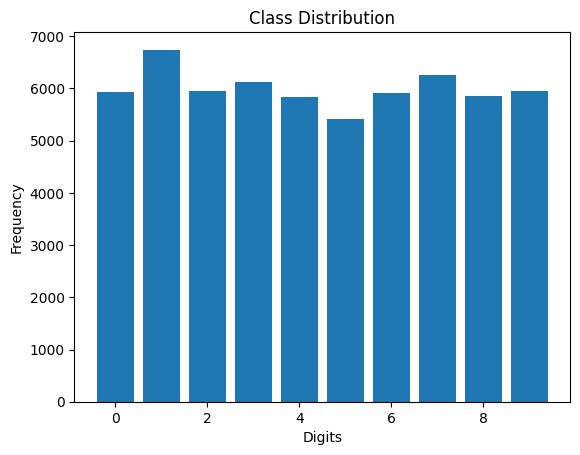

In [3]:
import matplotlib.pyplot as plt

unique, counts = np.unique(y_train, return_counts=True)

plt.bar(unique, counts)
plt.title("Class Distribution")
plt.xlabel("Digits")
plt.ylabel("Frequency")
plt.show()

In [4]:
def create_model(lr=0.001):
    from tensorflow.keras.optimizers import Adam
    model = Sequential([
        Flatten(input_shape=(28,28)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [5]:
def fitness(ind):
    lr, batch = ind
    model = create_model(lr)
    model.fit(x_train, y_train_cat, epochs=1, batch_size=int(batch), verbose=0)
    _, acc = model.evaluate(x_test, y_test_cat, verbose=0)
    return acc

In [6]:
def create_population(n):
    return [[random.uniform(0.0001,0.01), random.choice([32,64,128])] for _ in range(n)]

In [7]:
def selection(pop, fit):
    return [x for _,x in sorted(zip(fit,pop), reverse=True)][:len(pop)//2]

In [8]:
def crossover(p1,p2):
    return [(p1[0]+p2[0])/2, random.choice([p1[1],p2[1]])]

In [9]:
def mutation(ind):
    if random.random()<0.2:
        ind[0]=random.uniform(0.0001,0.01)
    return ind

In [10]:
pop=create_population(6)
for g in range(3):
    fit=[fitness(i) for i in pop]
    sel=selection(pop,fit)
    new=sel.copy()
    while len(new)<len(pop):
        c=crossover(*random.sample(sel,2))
        new.append(mutation(c))
    pop=new

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
from tensorflow.keras.callbacks import EarlyStopping

# Stop training when validation accuracy stops improving
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

best = pop[0]

model = create_model(best[0])

history = model.fit(
    x_train, y_train_cat,
    epochs=15,                      # allow more epochs (early stopping will control)
    batch_size=int(best[1]),
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9241 - loss: 0.2581 - val_accuracy: 0.9431 - val_loss: 0.2022
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9535 - loss: 0.1612 - val_accuracy: 0.9582 - val_loss: 0.1560
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9628 - loss: 0.1341 - val_accuracy: 0.9581 - val_loss: 0.1544
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9655 - loss: 0.1250 - val_accuracy: 0.9500 - val_loss: 0.2320
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9694 - loss: 0.1106 - val_accuracy: 0.9585 - val_loss: 0.1503
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9699 - loss: 0.1081 - val_accuracy: 0.9585 - val_loss: 0.1720
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9736 - loss: 0.1004 - val_accuracy: 0.9697 - val_loss: 0.1273
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9755 - loss: 0.0939 -

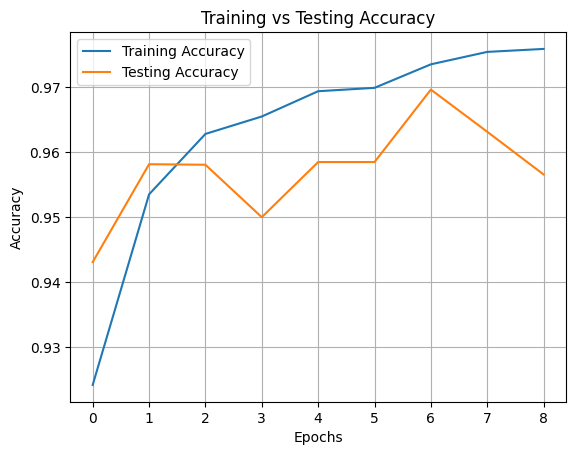

In [23]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Testing Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy")
plt.legend()
plt.grid()

plt.show()

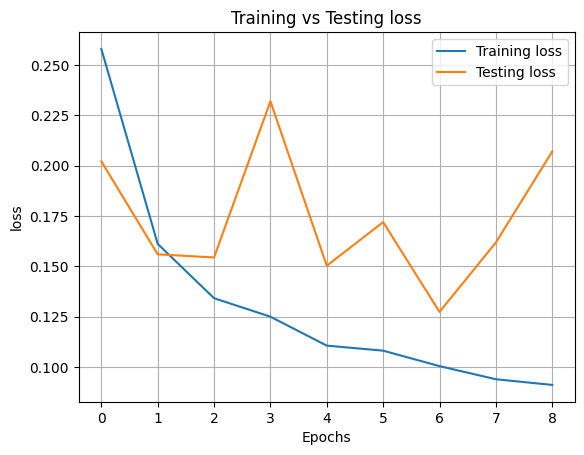

In [24]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Testing loss')

plt.xlabel("Epochs")
plt.ylabel("loss")
plt.title("Training vs Testing loss")
plt.legend()
plt.grid()

plt.show()

In [13]:
pred=np.argmax(model.predict(x_test),axis=1)
cm=confusion_matrix(y_test,pred)
print(cm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
[[ 961    0    6    0    0    2    2    1    8    0]
 [   1 1112    3    0    0    1    2    1   15    0]
 [   1    0 1009    3    6    0    4    2    6    1]
 [   0    0    7  975    0    8    0    6   12    2]
 [   0    1    2    0  959    0    5    0    1   14]
 [   2    0    1   21    1  851    2    0   10    4]
 [   9    4    0    1    2    6  927    0    9    0]
 [   0    5   12    2    3    0    1  992    3   10]
 [   3    1    6    4    4    1    2    2  948    3]
 [   2    2    0   15   17    8    0    3    3  959]]


In [14]:
pip install streamlit pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 103.6 MB/s eta 0:00:00


In [15]:
model.save("digit_model.h5")

In [17]:
from google.colab import files
uploaded = files.upload()

Saving download.png to download.png


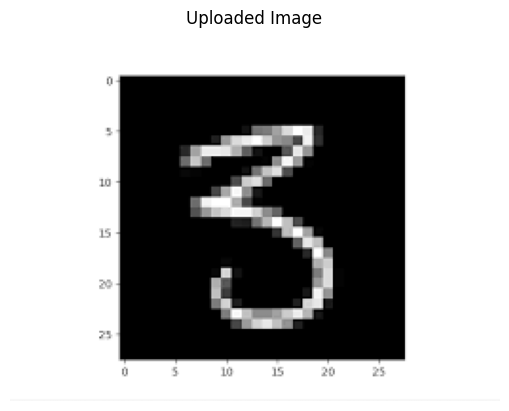

In [18]:
from PIL import Image
import matplotlib.pyplot as plt

file_name = list(uploaded.keys())[0]

img = Image.open(file_name).convert('L')  # grayscale

plt.imshow(img, cmap='gray')
plt.title("Uploaded Image")
plt.axis('off')
plt.show()

In [19]:
import numpy as np

img = img.resize((28, 28))


img_array = np.array(img)

img_array = img_array / 255.0

img_array = img_array.reshape(1, 28, 28)

In [20]:
from tensorflow.keras.models import load_model

model = load_model("digit_model.h5")

In [21]:
prediction = model.predict(img_array)
digit = np.argmax(prediction)

print("Predicted Digit:", digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Predicted Digit: 3


In [22]:
confidence = np.max(prediction)
print("Confidence:", confidence)

Confidence: 0.99459934
